# Telecom X - Parte 2: Prediccion de Cancelacion (Churn)

Notebook independiente para preparar los datos, entrenar modelos de clasificacion, comparar su desempeno e interpretar los factores que explican la cancelacion de clientes.

## Objetivos del notebook

- Cargar el archivo tratado en la Parte 1.
- Preparar variables para modelado eliminando columnas irrelevantes y codificando categoricas.
- Verificar el balance de clases y justificar si hace falta balanceo adicional.
- Analizar correlaciones y relaciones dirigidas con churn.
- Entrenar dos modelos con enfoques distintos: uno sensible a escala y otro basado en arboles.
- Evaluar accuracy, precision, recall, F1 y matrices de confusion.
- Interpretar variables relevantes y cerrar con recomendaciones estrategicas.

## 1. Librerias y configuracion

### Importaciones principales
Se cargan librerias para manipulacion de datos, visualizacion y Machine Learning.

### Configuracion visual
Se define un estilo base para que los graficos mantengan una presentacion uniforme.

In [1]:
from pathlib import Path
from urllib.request import urlopen
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")

## 2. Carga del archivo tratado

### Origen del dataset
Se busca el CSV limpio generado en la Parte 1 dentro de la carpeta `data`.

### Plan de respaldo
Si el archivo no existe, se reconstruye a partir de la fuente original y se guarda localmente para reutilizarlo.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
workspace_root = Path.cwd()
csv_preferido = workspace_root / "data" / "telecomx_parte1_limpio.csv"

if csv_preferido.exists():
    df = pd.read_csv(csv_preferido)
    print(f"CSV cargado: {csv_preferido}")
else:
    with urlopen(DATA_URL) as response:
        datos = json.load(response)

    df = pd.json_normalize(datos, sep="_")
    columnas_texto = df.select_dtypes(include=["object", "string"]).columns
    df[columnas_texto] = df[columnas_texto].apply(lambda serie: serie.str.strip())
    df[columnas_texto] = df[columnas_texto].replace({"": pd.NA})
    df["account_Charges_Total"] = pd.to_numeric(df["account_Charges_Total"], errors="coerce")

    df = df.dropna(subset=["Churn"]).copy()
    df.loc[
        df["account_Charges_Total"].isna() & (df["customer_tenure"] == 0),
        "account_Charges_Total",
    ] = 0

    (workspace_root / "data").mkdir(exist_ok=True)
    df.to_csv(csv_preferido, index=False)
    print(f"CSV limpio generado y guardado en: {csv_preferido}")

print(f"Dimensiones del dataset: {df.shape}")
df.head()

CSV cargado: c:\Users\DIRAC-DESK2\Desktop\Challenge TelecomX_LATAM_2\data\telecomx_parte1_limpio.csv
Dimensiones del dataset: (7043, 21)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 3. Preparacion de datos para Machine Learning

### Limpieza final para modelado
Se validan tipos, se completan valores necesarios y se asegura que la variable objetivo quede lista.

### Eliminacion de columnas irrelevantes
Se excluye el identificador unico del cliente para evitar ruido en el entrenamiento.

### Balance de clases
Se calcula la proporcion entre churn y no churn para revisar si el problema requiere tecnicas de balanceo.

In [3]:
df_modelo = df.copy()
df_modelo["account_Charges_Total"] = pd.to_numeric(df_modelo["account_Charges_Total"], errors="coerce")
df_modelo = df_modelo.dropna(subset=["Churn"]).copy()
df_modelo.loc[
    df_modelo["account_Charges_Total"].isna() & (df_modelo["customer_tenure"] == 0),
    "account_Charges_Total",
] = 0

df_modelo["Churn_binario"] = df_modelo["Churn"].map({"Yes": 1, "No": 0})

target = "Churn_binario"
columna_id = "customerID"
X = df_modelo.drop(columns=["Churn", columna_id, target])
y = df_modelo[target]

columnas_numericas = X.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=["number"]).columns.tolist()

proporcion_churn = y.value_counts(normalize=True).sort_index().mul(100).round(2)
tabla_balance = pd.DataFrame({
    "cantidad": y.value_counts().sort_index(),
    "porcentaje": proporcion_churn,
})
tabla_balance.index = ["No churn", "Churn"]

print(f"Filas para modelado: {len(df_modelo)}")
print(f"Variables predictoras despues de eliminar {columna_id}: {X.shape[1]}")
print(f"Numericas: {len(columnas_numericas)} | Categoricas: {len(columnas_categoricas)}")
print("\nProporcion de clases:")
display(tabla_balance)

if proporcion_churn.max() >= 80:
    print("Existe desbalance fuerte. Conviene evaluar tecnicas de balanceo como SMOTE o ajuste de pesos.")
else:
    print("El desbalance es moderado. Se puede modelar sin balanceo inicial y revisar recall/precision antes de complejizar el pipeline.")

X.head()

Filas para modelado: 7043
Variables predictoras despues de eliminar customerID: 19
Numericas: 4 | Categoricas: 15

Proporcion de clases:


,cantidad,porcentaje
No churn,5174,73.46
Churn,1869,26.54


El desbalance es moderado. Se puede modelar sin balanceo inicial y revisar recall/precision antes de complejizar el pipeline.


,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 4. Correlacion y analisis dirigido

### Matriz de correlacion
Se observan relaciones entre variables numericas y la cancelacion.

### Analisis de permanencia
Se compara el tiempo de contrato entre clientes que cancelan y quienes permanecen.

### Analisis de gasto acumulado
Se revisa como el cargo total se asocia con la probabilidad de churn.

### Seleccion inicial de variables
Se utiliza informacion mutua para detectar variables con mayor señal predictiva.

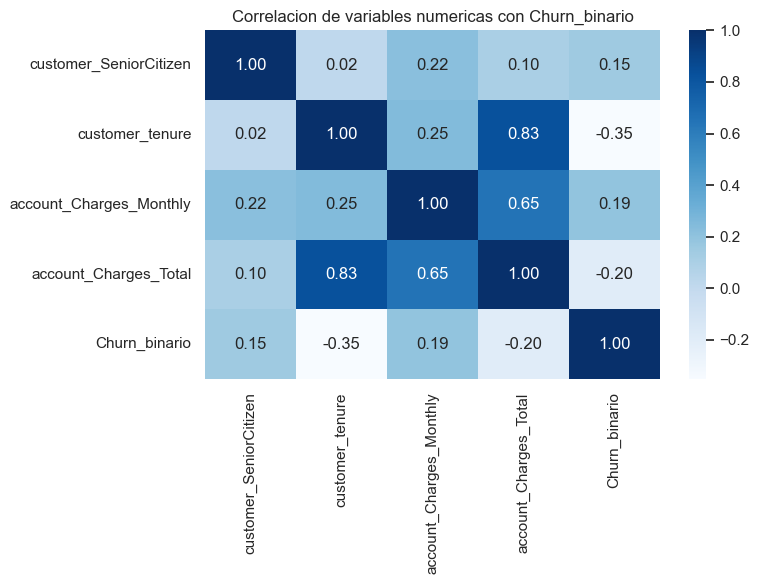

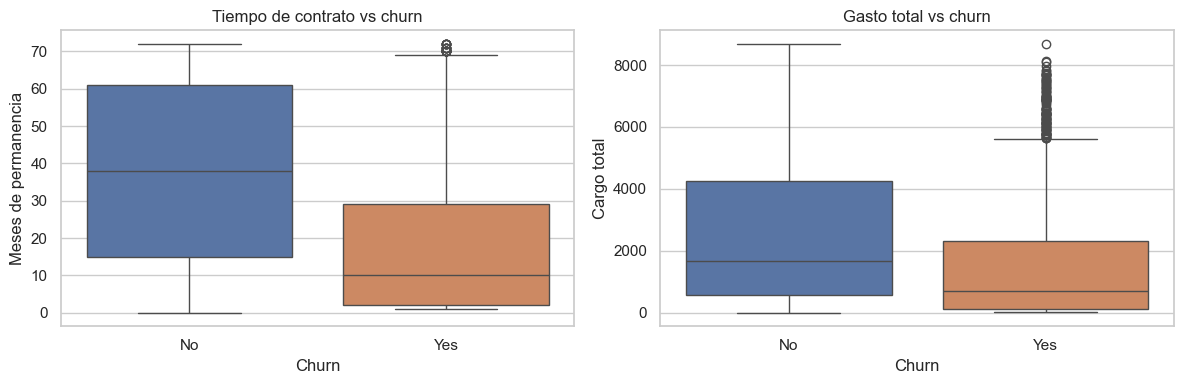

,variable,mutual_info
36,account_Contract_Month-to-month,0.099655
1,customer_tenure,0.071161
38,account_Contract_Two year,0.063383
18,internet_OnlineSecurity_No,0.062940
27,internet_TechSupport_No,0.054904
2,account_Charges_Monthly,0.047192
43,account_PaymentMethod_Electronic check,0.043943
3,account_Charges_Total,0.043234
16,internet_InternetService_Fiber optic,0.040920
21,internet_OnlineBackup_No,0.035179


In [4]:
corr_cols = columnas_numericas + [target]
corr_df = df_modelo[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlacion de variables numericas con Churn_binario")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_modelo, x="Churn", y="customer_tenure", ax=axes[0], hue="Churn", legend=False)
axes[0].set_title("Tiempo de contrato vs churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Meses de permanencia")

sns.boxplot(data=df_modelo, x="Churn", y="account_Charges_Total", ax=axes[1], hue="Churn", legend=False)
axes[1].set_title("Gasto total vs churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Cargo total")
plt.tight_layout()
plt.show()

X_dummies = pd.get_dummies(X, drop_first=False)
mi = mutual_info_classif(X_dummies.fillna(0), y, random_state=42)
mi_df = (
    pd.DataFrame({"variable": X_dummies.columns, "mutual_info": mi})
    .sort_values("mutual_info", ascending=False)
    .head(15)
)

display(mi_df)

## 5. Entrenamiento y comparacion de modelos

### Separacion de entrenamiento y prueba
Se divide la base en conjuntos train y test para medir generalizacion.

### Modelo sensible a escala
La Regresion Logistica usa estandarizacion porque depende de magnitudes comparables entre variables.

### Modelo basado en arboles
Random Forest se entrena sin escalado porque no depende de la escala de las variables.

### Revision de ajuste
Se comparan metricas de train y test para detectar overfitting o underfitting.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

preprocesador_escalado = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            columnas_numericas,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            columnas_categoricas,
        ),
    ]
)

preprocesador_sin_escalado = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            columnas_numericas,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            columnas_categoricas,
        ),
    ]
)

configuracion_modelos = {
    "LogisticRegression": {
        "pipeline": Pipeline([
            ("preprocess", preprocesador_escalado),
            ("model", LogisticRegression(max_iter=2000, random_state=42)),
        ]),
        "usa_escalado": True,
    },
    "RandomForest": {
        "pipeline": Pipeline([
            ("preprocess", preprocesador_sin_escalado),
            ("model", RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            )),
        ]),
        "usa_escalado": False,
    },
}

resultados = []
pipelines_entrenados = {}

for nombre, config in configuracion_modelos.items():
    pipe = config["pipeline"]
    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)
    y_proba_test = pipe.predict_proba(X_test)[:, 1]

    resultados.append({
        "modelo": nombre,
        "usa_escalado": config["usa_escalado"],
        "accuracy_train": accuracy_score(y_train, y_pred_train),
        "accuracy_test": accuracy_score(y_test, y_pred_test),
        "precision_test": precision_score(y_test, y_pred_test),
        "recall_test": recall_score(y_test, y_pred_test),
        "f1_test": f1_score(y_test, y_pred_test),
        "roc_auc_test": roc_auc_score(y_test, y_proba_test),
        "gap_accuracy": accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test),
    })
    pipelines_entrenados[nombre] = pipe

resultados_df = pd.DataFrame(resultados).sort_values("roc_auc_test", ascending=False)
display(resultados_df.round(4))

print("\nLectura rapida del ajuste:")
for fila in resultados_df.itertuples(index=False):
    if fila.gap_accuracy > 0.08:
        estado = "posible overfitting"
    elif fila.accuracy_test < 0.75:
        estado = "posible underfitting"
    else:
        estado = "ajuste razonable"
    print(f"- {fila.modelo}: {estado} (gap_accuracy={fila.gap_accuracy:.4f})")

,modelo,usa_escalado,accuracy_train,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,gap_accuracy
0,LogisticRegression,True,0.8097,0.7974,0.6383,0.5472,0.5893,0.8404,0.0123
1,RandomForest,False,0.9327,0.7866,0.6239,0.4938,0.5512,0.8311,0.1461



Lectura rapida del ajuste:
- LogisticRegression: ajuste razonable (gap_accuracy=0.0123)
- RandomForest: posible overfitting (gap_accuracy=0.1461)


## 6. Evaluacion e interpretacion

### Matrices de confusion
Se visualiza el tipo de errores que comete cada modelo.

### Metricas del mejor modelo
Se analiza precision, recall, F1 y desempeno global del modelo mas competitivo.

### Variables mas influyentes
Se identifican los atributos que mas pesan en la prediccion para traducirlos a decisiones de negocio.

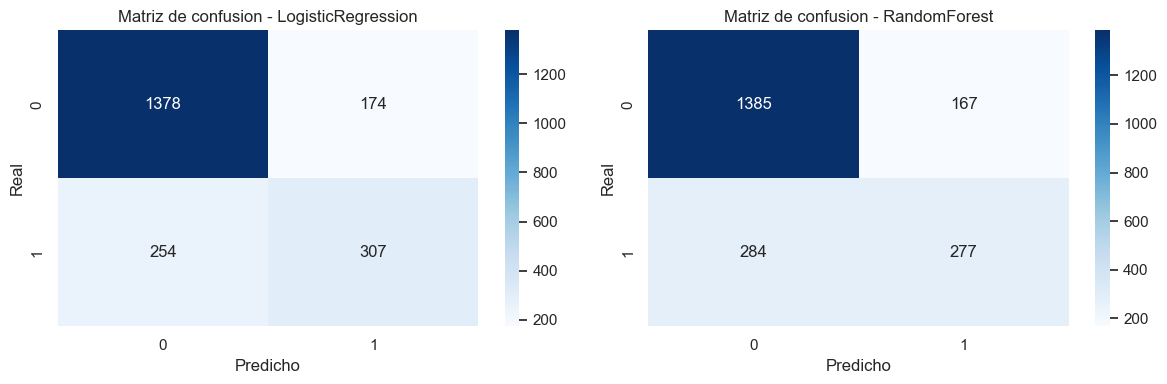

Mejor modelo segun ROC-AUC en test: LogisticRegression

Reporte de clasificacion del mejor modelo:
              precision    recall  f1-score   support

           0     0.8444    0.8879    0.8656      1552
           1     0.6383    0.5472    0.5893       561

    accuracy                         0.7974      2113
   macro avg     0.7413    0.7176    0.7274      2113
weighted avg     0.7896    0.7974    0.7922      2113


Top 10 variables relevantes - LogisticRegression


,variable,importancia
1,num__customer_tenure,1.472860
3,num__account_Charges_Total,0.723144
38,cat__account_Contract_Two year,0.719663
36,cat__account_Contract_Month-to-month,0.583022
15,cat__internet_InternetService_DSL,0.363712
39,cat__account_PaperlessBilling_No,0.354400
11,cat__phone_PhoneService_Yes,0.341093
29,cat__internet_TechSupport_Yes,0.302755
12,cat__phone_MultipleLines_No,0.284102
9,cat__customer_Dependents_Yes,0.249339



Top 10 variables relevantes - RandomForest


,variable,importancia
1,num__customer_tenure,0.147588
3,num__account_Charges_Total,0.139297
2,num__account_Charges_Monthly,0.110610
36,cat__account_Contract_Month-to-month,0.077583
27,cat__internet_TechSupport_No,0.039331
43,cat__account_PaymentMethod_Electronic check,0.036358
18,cat__internet_OnlineSecurity_No,0.034630
16,cat__internet_InternetService_Fiber optic,0.032912
38,cat__account_Contract_Two year,0.023141
21,cat__internet_OnlineBackup_No,0.018557


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

resumen_importancias = {}

for indice, (nombre, pipe) in enumerate(pipelines_entrenados.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[indice])
    axes[indice].set_title(f"Matriz de confusion - {nombre}")
    axes[indice].set_xlabel("Predicho")
    axes[indice].set_ylabel("Real")

    feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
    if nombre == "LogisticRegression":
        importancias = np.abs(pipe.named_steps["model"].coef_[0])
    else:
        importancias = pipe.named_steps["model"].feature_importances_

    resumen_importancias[nombre] = (
        pd.DataFrame({"variable": feature_names, "importancia": importancias})
        .sort_values("importancia", ascending=False)
        .head(10)
    )

plt.tight_layout()
plt.show()

mejor_modelo_nombre = resultados_df.iloc[0]["modelo"]
mejor_pipe = pipelines_entrenados[mejor_modelo_nombre]
y_pred_best = mejor_pipe.predict(X_test)

print(f"Mejor modelo segun ROC-AUC en test: {mejor_modelo_nombre}")
print("\nReporte de clasificacion del mejor modelo:")
print(classification_report(y_test, y_pred_best, digits=4))

for nombre, tabla in resumen_importancias.items():
    print(f"\nTop 10 variables relevantes - {nombre}")
    display(tabla)

## Conclusiones estrategicas

- La cancelacion se concentra especialmente en clientes con menor permanencia y menor cargo total acumulado, lo que apunta a fuga temprana.
- La Regresion Logistica se beneficia de la estandarizacion porque optimiza coeficientes sobre variables en distintas escalas.
- Random Forest permite contrastar un enfoque no lineal que no depende de la escala y aporta una segunda lectura de importancia de variables.
- Si el recall del churn resulta insuficiente, el siguiente ajuste natural es mover el umbral de decision o usar pesos de clase antes de aplicar tecnicas de remuestreo.
- Las acciones de retencion deben priorizar clientes nuevos, contratos flexibles y perfiles con senales de bajo compromiso de permanencia.